In [13]:
# instalacija i ubacivanje potrebnih biblioteka

import sys
!pip install opencv-python matplotlib
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [14]:
left_image_path = 'levo3.jpg'
right_image_path = 'desno3.jpg'

left_image = cv2.imread(left_image_path)
right_image = cv2.imread(right_image_path)

In [15]:
# provera da li su slike uspesno ucitane

print(left_image.shape)
print(right_image.shape)

(3000, 4000, 3)
(3000, 4000, 3)


In [16]:
# SIFT algoritam je najbolje radi sa slikama u nijansama sive
left_image_gray = cv2.cvtColor(left_image, cv2.COLOR_BGR2GRAY)
right_image_gray = cv2.cvtColor(right_image, cv2.COLOR_BGR2GRAY)

# konverzija u RGB format, jer cv2 ucitava slike u BGR formatu
left_image_rgb = cv2.cvtColor(left_image, cv2.COLOR_BGR2RGB)
right_image_rgb = cv2.cvtColor(right_image, cv2.COLOR_BGR2RGB)

In [17]:
# preko SIFT algoritma odredjujemo kljucne tacke i njihove deskriptore na svakoj slici

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(left_image_gray, None)
kp2, des2 = sift.detectAndCompute(right_image_gray, None)

print(f"Ključnih tačaka na prvoj slici: {len(kp1)}")
print(f"Format deskriptora prve slike je velika matrica formata {des1.shape}")
print(f"Ključnih tačaka na drugoj slici: {len(kp2)}")
print(f"Format deskriptora druge slike je takodje velika matrica formata {des2.shape}")

Ključnih tačaka na prvoj slici: 6616
Format deskriptora prve slike je velika matrica formata (6616, 128)
Ključnih tačaka na drugoj slici: 10335
Format deskriptora druge slike je takodje velika matrica formata (10335, 128)


In [18]:
# preko Brute Force Matcher-a odredjujemo podudaranja kljucnih tacaka

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2)
good_matches = []

for m, n in matches:
  if m.distance < 0.5*n.distance:
    good_matches.append(m)

print(f"Ukupno podudaranja: {len(matches)}")
print(f"Dobrih podudaranja nakon testa količnika: {len(good_matches)}")

Ukupno podudaranja: 6616
Dobrih podudaranja nakon testa količnika: 140


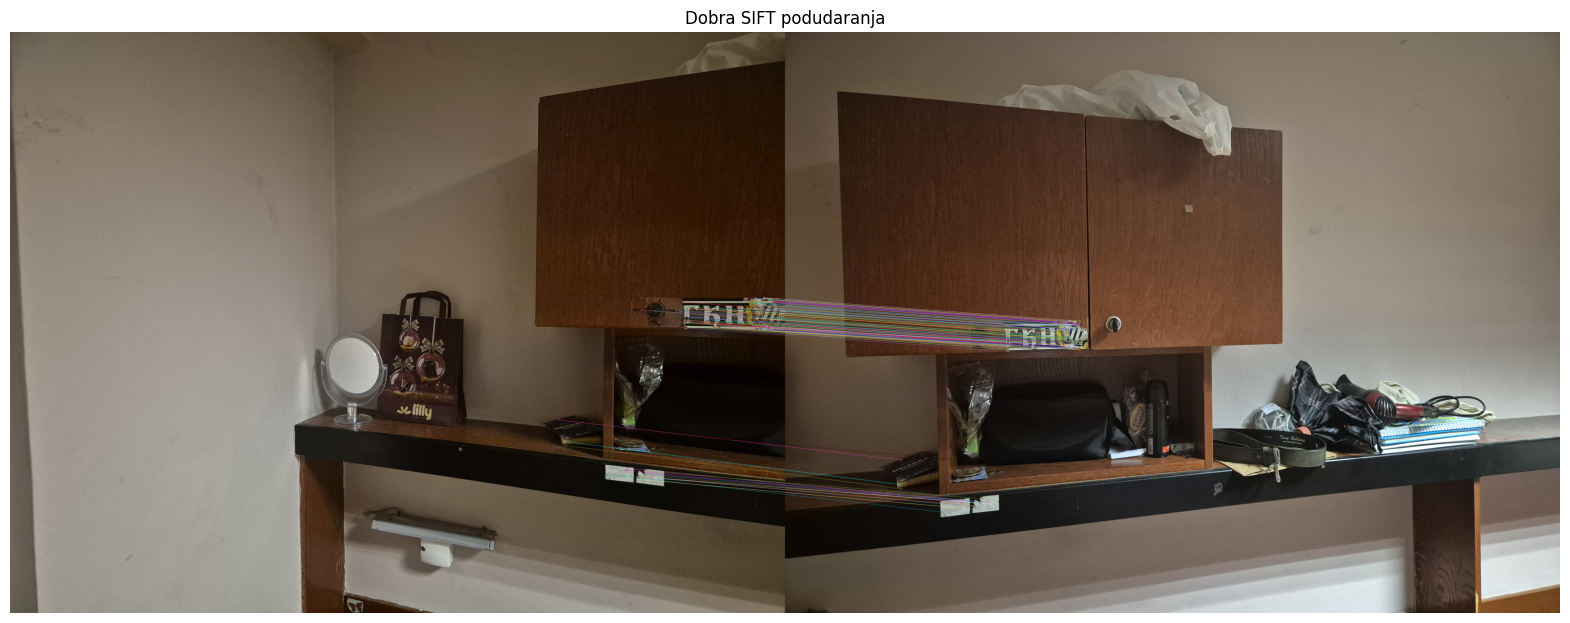

In [19]:
img_matches = cv2.drawMatchesKnn(left_image_rgb, kp1, right_image_rgb, kp2, [good_matches], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(20,10))
plt.imshow(img_matches)
plt.title("Dobra SIFT podudaranja")
plt.axis('off')
plt.show()

In [20]:
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches])

In [21]:
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5)

In [22]:
h1, w1 = left_image_rgb.shape[:2]
h2, w2 = right_image_rgb.shape[:2]

output_width = w1 + w2
output_height = max(h1, h2)
output_size = (output_width, output_height)

warped_image_right = cv2.warpPerspective(right_image_rgb, H, output_size)

In [23]:
panorama = np.zeros((output_height, output_width, 3), dtype=left_image_rgb.dtype)
panorama[0:h1, 0:w1] = left_image_rgb
panorama = cv2.addWeighted(panorama, 0.5, warped_image_right, 0.5, 0)

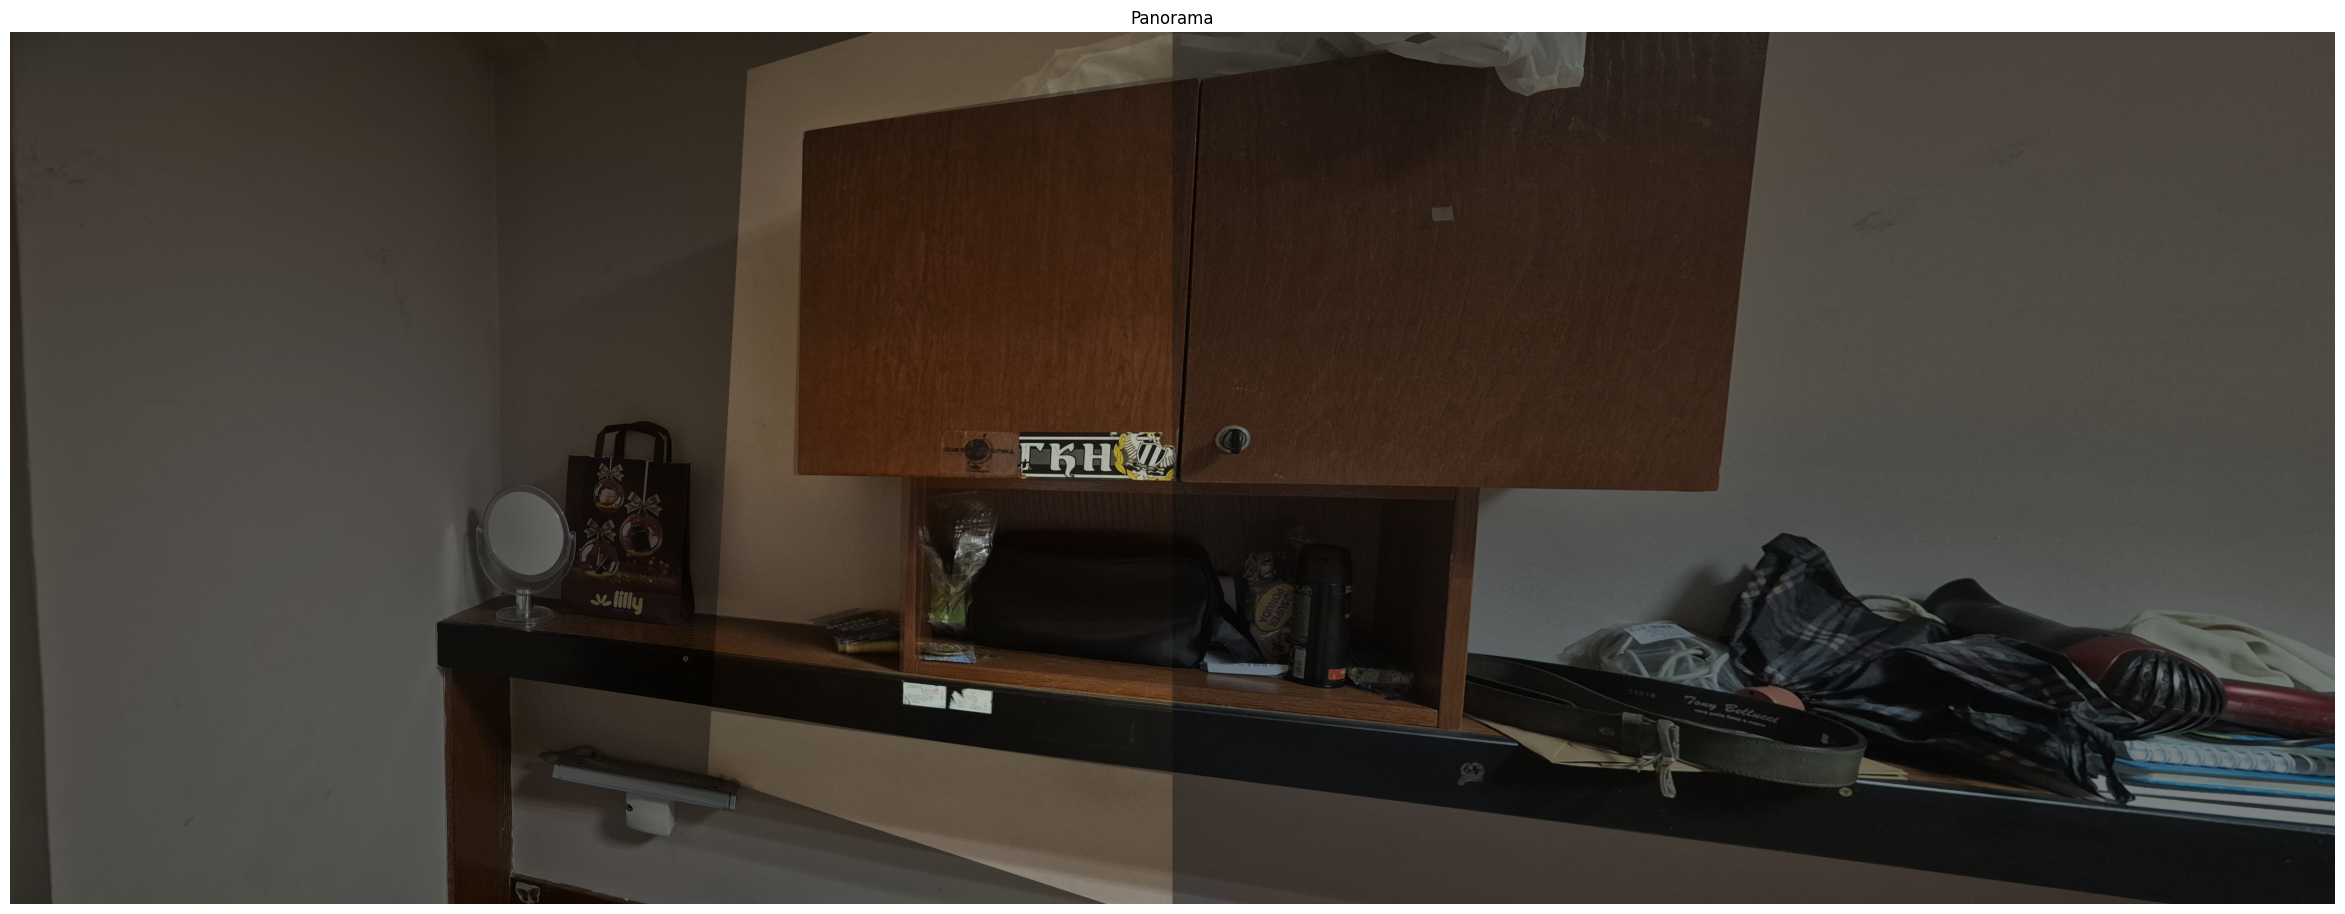

In [24]:
plt.figure(figsize=(30,15))
plt.imshow(panorama)
plt.title("Panorama")
plt.axis('off')
plt.show()